In [ ]:
# Check if dataset exists, if not, show instructions
import os

if not os.path.exists("./Train") or not os.path.exists("./Test"):
    print("=" * 60)
    print("⚠️  DATASET NOT FOUND!")
    print("=" * 60)
    print("\n📥 Please download the Brain Tumor MRI Dataset from:")
    print("   https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset")
    print("\n📁 After downloading, extract the folders to:")
    print("   ./Train/  and  ./Test/")
    print("\n✅ Expected structure:")
    print("   ./Train/glioma/")
    print("   ./Train/meningioma/")
    print("   ./Train/notumor/")
    print("   ./Train/pituitary/")
    print("   (same for Test folder)")
    print("\n🔧 Alternative: Use Kaggle API (optional)")
    print("   !kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset")
    print("   !unzip brain-tumor-mri-dataset.zip")
    print("=" * 60)
else:
    print("✅ Dataset found! Ready to train.")

In [ ]:
import os, copy, random, json, time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, models
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc,
)
from sklearn.preprocessing import label_binarize

## Configuration

In [2]:
CONFIG = {
    "train_dir":   "./Train",
    "test_dir":    "./Test",
    "output_dir":  "./outputs",
    "num_classes": 4,
    "image_size":  224,
    "epochs":      50,
    "batch_size":  32,
    "num_workers": 4,
    "learning_rate": 1e-4,
    "weight_decay":  1e-4,
    "lr_patience":   5,
    "early_stop_patience": 10,
    "seed": 42,
    "gradcam_samples_per_class": 3,
}

CLASS_NAMES = ["glioma", "meningioma", "notumor", "pituitary"]

## Seed & Device

In [3]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(CONFIG["seed"])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Device: cpu


## Data Transforms

In [4]:
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]
sz   = CONFIG["image_size"]

train_tf = transforms.Compose([
    transforms.Resize((sz + 32, sz + 32)),
    transforms.RandomCrop(sz),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.1, hue=0.05),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.85, 1.15), shear=5),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.15)),
])

val_tf = transforms.Compose([
    transforms.Resize((sz, sz)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

## Dataset Loading

In [5]:
full_train = datasets.ImageFolder(CONFIG["train_dir"], transform=train_tf)
test_ds    = datasets.ImageFolder(CONFIG["test_dir"],  transform=val_tf)

n_total = len(full_train)
n_val   = int(0.20 * n_total)
n_train = n_total - n_val

generator = torch.Generator().manual_seed(CONFIG["seed"])
train_ds, val_ds = torch.utils.data.random_split(full_train, [n_train, n_val], generator=generator)

val_copy = copy.deepcopy(full_train)
val_copy.transform = val_tf
val_ds.dataset = val_copy

print(f"Train: {n_train} | Val: {n_val} | Test: {len(test_ds)}")
print(f"Classes: {full_train.classes}")

Train: 4480 | Val: 1120 | Test: 1600
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


## Weighted Sampler (Class Imbalance)

In [6]:
labels = [full_train.targets[i] for i in train_ds.indices]
class_counts  = np.bincount(labels)
class_weights = 1.0 / class_counts
sample_weights = [class_weights[l] for l in labels]

sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

nw = CONFIG["num_workers"]
train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, num_workers=nw, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=CONFIG["batch_size"], shuffle=False,  num_workers=nw, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=CONFIG["batch_size"], shuffle=False,  num_workers=nw, pin_memory=True)

print("Class counts (train):", dict(zip(CLASS_NAMES, class_counts)))

Class counts (train): {'glioma': 1115, 'meningioma': 1123, 'notumor': 1111, 'pituitary': 1131}


## Model — DenseNet121

In [7]:
model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)

for param in model.parameters():
    param.requires_grad = False

in_features = model.classifier.in_features

model.classifier = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(in_features, 512),
    nn.ReLU(inplace=True),
    nn.BatchNorm1d(512),
    nn.Dropout(p=0.3),
    nn.Linear(512, CONFIG["num_classes"]),
)

for param in model.classifier.parameters():
    param.requires_grad = True

model = model.to(device)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total:,} | Trainable: {trainable:,} ({100*trainable/total:.1f}%)")

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to C:\Users\FABHOSTPYTHON/.cache\torch\hub\checkpoints\densenet121-a639ec97.pth


  0%|          | 0.00/30.8M [00:00<?, ?B/s]

Total params: 7,481,732 | Trainable: 527,876 (7.1%)


## Training Utilities

In [8]:
def train_one_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(loader, desc="  Train", leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast(enabled=(scaler is not None)):
            outputs = model(images)
            loss = criterion(outputs, labels)
        if scaler is not None:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []
    for images, labels in tqdm(loader, desc="  Eval ", leave=False):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        probs = torch.softmax(outputs, 1)
        preds = probs.argmax(1)
        running_loss += loss.item() * images.size(0)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
    return running_loss / total, correct / total, np.array(all_preds), np.array(all_labels), np.array(all_probs)

## Training Loop

In [ ]:
out_dir = Path(CONFIG["output_dir"])
out_dir.mkdir(parents=True, exist_ok=True)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CONFIG["learning_rate"], weight_decay=CONFIG["weight_decay"]
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", patience=CONFIG["lr_patience"], factor=0.5, min_lr=1e-7
)
scaler = torch.cuda.amp.GradScaler() if device.type == "cuda" else None

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0
no_improve   = 0
fine_tuned   = False
WARMUP_EPOCHS = 5
best_path = out_dir / "best_model.pth"

for epoch in range(1, CONFIG["epochs"] + 1):
    t0 = time.time()

    if epoch == WARMUP_EPOCHS + 1 and not fine_tuned:
        for param in model.parameters():
            param.requires_grad = True
        optimizer = optim.Adam([
            {"params": model.features.parameters(),    "lr": CONFIG["learning_rate"] * 0.1},
            {"params": model.classifier.parameters(),  "lr": CONFIG["learning_rate"]},
        ], weight_decay=CONFIG["weight_decay"])
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="max", patience=CONFIG["lr_patience"], factor=0.5, min_lr=1e-7
        )
        fine_tuned = True
        print("\n[Fine-tune] Full model unfrozen.")

    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, scaler)
    vl_loss, vl_acc, _, _, _ = evaluate(model, val_loader, criterion)
    scheduler.step(vl_acc)

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(vl_loss)
    history["val_acc"].append(vl_acc)

    flag = ""
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        no_improve = 0
        torch.save(model.state_dict(), best_path)
        flag = "  ✓ best"
    else:
        no_improve += 1

    lr_now = optimizer.param_groups[-1]["lr"]
    print(f"Epoch {epoch:03d}/{CONFIG['epochs']} | "
          f"Train Loss {tr_loss:.4f} Acc {tr_acc:.4f} | "
          f"Val Loss {vl_loss:.4f} Acc {vl_acc:.4f} | "
          f"LR {lr_now:.2e} | {time.time()-t0:.1f}s{flag}")

    if no_improve >= CONFIG["early_stop_patience"]:
        print(f"\nEarly stopping after {epoch} epochs.")
        break

print(f"\nBest Val Accuracy: {best_val_acc:.4f}")

## Training Curves

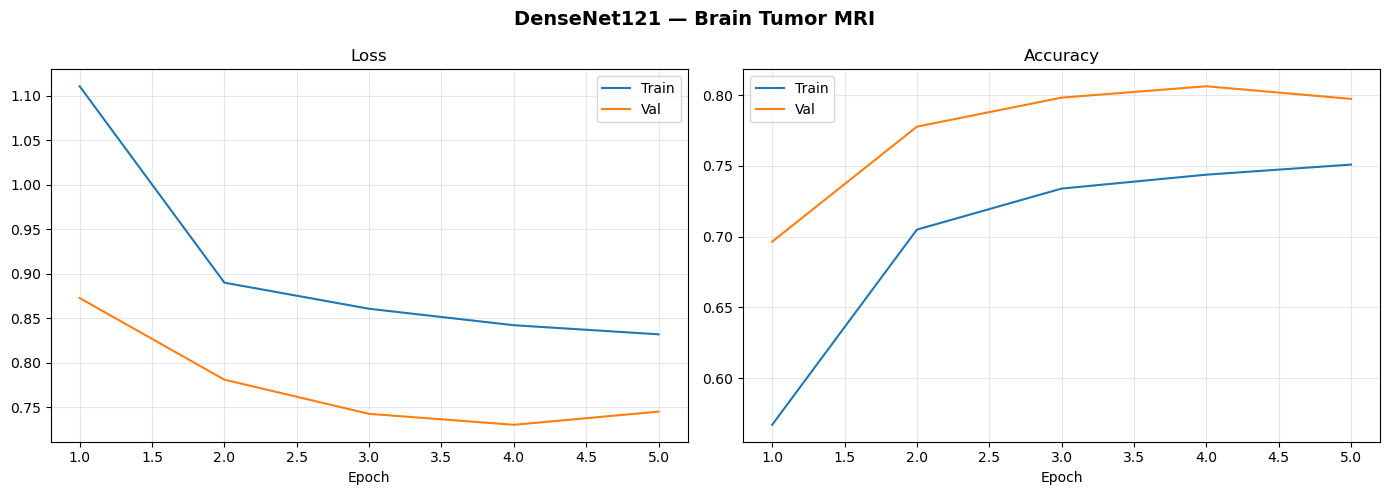

In [10]:
epochs_range = range(1, len(history["train_loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, history["train_loss"], label="Train")
axes[0].plot(epochs_range, history["val_loss"],   label="Val")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history["train_acc"], label="Train")
axes[1].plot(epochs_range, history["val_acc"],   label="Val")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle("DenseNet121 — Brain Tumor MRI", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(out_dir / "training_curves.png", dpi=150)
plt.show()

## Test Set Evaluation

In [11]:
model.load_state_dict(torch.load(best_path, map_location=device))
te_loss, te_acc, preds, labels, probs = evaluate(model, test_loader, criterion)
print(f"Test Loss: {te_loss:.4f}  |  Test Accuracy: {te_acc:.4f}")

Test Loss: 0.8071  |  Test Accuracy: 0.7675


## Confusion Matrix

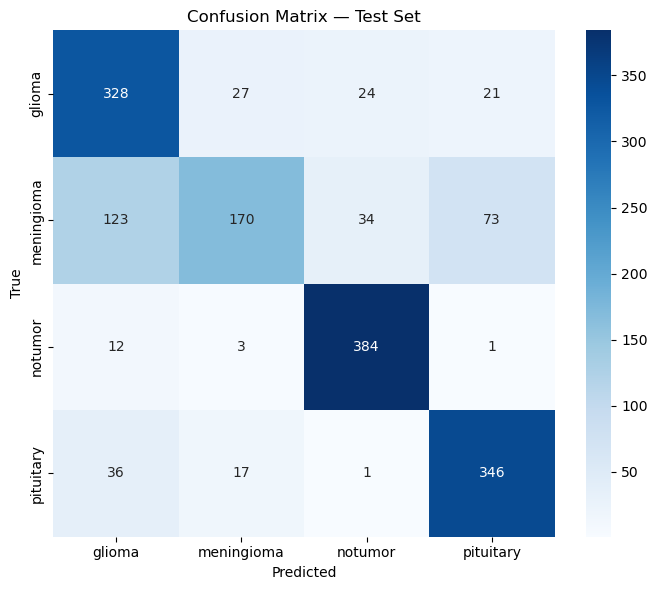

In [12]:
cm = confusion_matrix(labels, preds)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.savefig(out_dir / "confusion_matrix.png", dpi=150)
plt.show()

## ROC Curves

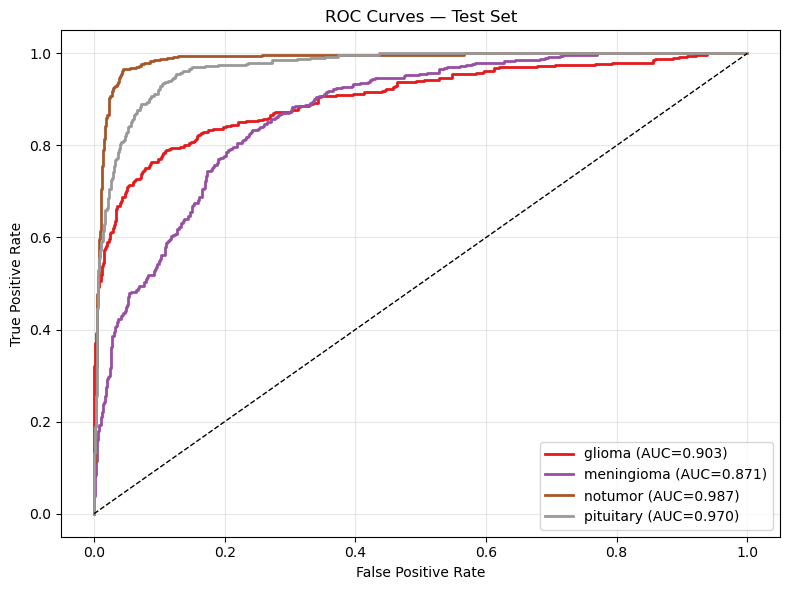

Macro-Average AUC: 0.9327


In [13]:
n_classes  = len(CLASS_NAMES)
labels_bin = label_binarize(labels, classes=list(range(n_classes)))
colors = plt.cm.Set1(np.linspace(0, 1, n_classes))

fig, ax = plt.subplots(figsize=(8, 6))
for i, (name, color) in enumerate(zip(CLASS_NAMES, colors)):
    fpr, tpr, _ = roc_curve(labels_bin[:, i], probs[:, i])
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC={auc(fpr, tpr):.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Test Set"); ax.legend(loc="lower right"); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(out_dir / "roc_curves.png", dpi=150)
plt.show()

macro_auc = roc_auc_score(labels_bin, probs, average="macro", multi_class="ovr")
print(f"Macro-Average AUC: {macro_auc:.4f}")

## Classification Report

In [14]:
report = classification_report(labels, preds, target_names=CLASS_NAMES, digits=4)
print(report)

with open(out_dir / "classification_report.txt", "w") as f:
    f.write(report)
    f.write(f"\nMacro-Average AUC: {macro_auc:.4f}\n")

              precision    recall  f1-score   support

      glioma     0.6573    0.8200    0.7297       400
  meningioma     0.7834    0.4250    0.5511       400
     notumor     0.8668    0.9600    0.9110       400
   pituitary     0.7846    0.8650    0.8228       400

    accuracy                         0.7675      1600
   macro avg     0.7730    0.7675    0.7537      1600
weighted avg     0.7730    0.7675    0.7537      1600



## Grad-CAM Visualisation

In [15]:
class GradCAM:
    def __init__(self, model):
        self.model = model
        self.gradients  = None
        self.activations = None
        target = model.features.denseblock4
        target.register_forward_hook(self._save_act)
        target.register_full_backward_hook(self._save_grad)

    def _save_act(self, m, inp, out):
        self.activations = out.detach()

    def _save_grad(self, m, gin, gout):
        self.gradients = gout[0].detach()

    def generate(self, tensor, class_idx=None):
        self.model.eval()
        out  = self.model(tensor)
        pred = out.argmax(1).item()
        if class_idx is None:
            class_idx = pred
        self.model.zero_grad()
        out[0, class_idx].backward()
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam = torch.relu((weights * self.activations).sum(1, keepdim=True))
        cam = cam.squeeze().cpu().numpy()
        cam = cv2.resize(cam, (tensor.shape[3], tensor.shape[2]))
        cam -= cam.min()
        if cam.max() > 0:
            cam /= cam.max()
        return cam, pred


def denormalize(tensor):
    m = np.array([0.485, 0.456, 0.406])
    s = np.array([0.229, 0.224, 0.225])
    img = tensor.cpu().numpy().transpose(1, 2, 0)
    img = np.clip(s * img + m, 0, 1)
    return (img * 255).astype(np.uint8)

In [ ]:
gradcam = GradCAM(model)

class_indices = {c: [] for c in range(len(CLASS_NAMES))}
for idx, (_, lbl) in enumerate(test_ds.samples):
    class_indices[lbl].append(idx)

n_s  = CONFIG["gradcam_samples_per_class"]
cols = n_s * 2
rows = len(CLASS_NAMES)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))

for row, (cls_idx, cls_name) in enumerate(enumerate(CLASS_NAMES)):
    picks = random.sample(class_indices[cls_idx], min(n_s, len(class_indices[cls_idx])))

    for col, sidx in enumerate(picks):
        img_path = test_ds.samples[sidx][0]
        pil_img  = Image.open(img_path).convert("RGB")
        tensor   = val_tf(pil_img).unsqueeze(0).to(device)

        # ---- Predict ----
        with torch.no_grad():
            out = model(tensor)
            pred = out.argmax(1).item()

        pred_class = CLASS_NAMES[pred]

        # ---- Original Image ----
        orig = denormalize(tensor.squeeze(0))
        ax_o = axes[row, col * 2]
        ax_o.imshow(orig)
        ax_o.set_title(f"True: {cls_name}", fontsize=8)
        ax_o.axis("off")

        ax_h = axes[row, col * 2 + 1]


        if cls_name == "notumor" or pred_class == "notumor":
            ax_h.imshow(orig)
            ax_h.set_title(f"Pred: {pred_class} (No CAM)", fontsize=8)
            ax_h.axis("off")
            continue


        cam, _ = gradcam.generate(tensor)

        heat = cv2.applyColorMap((cam * 255).astype(np.uint8), cv2.COLORMAP_JET)
        heat = cv2.cvtColor(heat, cv2.COLOR_BGR2RGB)

        overlay = cv2.addWeighted(orig, 0.55, heat, 0.45, 0)

        ax_h.imshow(overlay)
        ax_h.set_title(f"Pred: {pred_class}", fontsize=8)
        ax_h.axis("off")

plt.suptitle("Grad-CAM — DenseNet121", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(out_dir / "gradcam_samples.png", dpi=150)
plt.show()

## Save Final Model

In [17]:
payload = {
    "model_state_dict": model.state_dict(),
    "class_names": CLASS_NAMES,
    "config": CONFIG,
}
torch.save(payload, out_dir / "brain_tumor_densenet121_full.pth")
with open(out_dir / "class_mapping.json", "w") as f:
    json.dump({str(i): n for i, n in enumerate(CLASS_NAMES)}, f, indent=2)

print("Saved to:", out_dir.resolve())

Saved to: E:\Sundar_Completed Projects\4831-AI based brain tumor detection using MRI images\outputs


Predicted Class : glioma
Confidence      : 0.9743


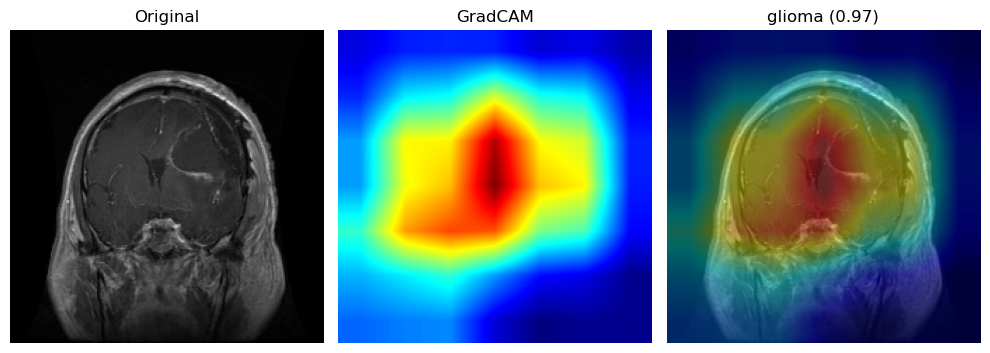

In [28]:
import torch
from torchvision import transforms, models
import torch.nn as nn
from PIL import Image
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ---------------- CONFIG ----------------
MODEL_PATH = "outputs/brain_tumor_densenet121_full.pth"
IMAGE_PATH = "Test/glioma/Te-gl_8.jpg"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------- LOAD MODEL ----------------
checkpoint = torch.load(MODEL_PATH, map_location=device)
CLASS_NAMES = checkpoint["class_names"]

model = models.densenet121(weights=None)
in_features = model.classifier.in_features

model.classifier = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(in_features, 512),
    nn.ReLU(inplace=True),
    nn.BatchNorm1d(512),
    nn.Dropout(0.3),
    nn.Linear(512, len(CLASS_NAMES)),
)

model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(device)
model.eval()

# ---------------- TRANSFORM ----------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

# ---------------- LOAD IMAGE ----------------
original_image = cv2.imread(IMAGE_PATH)
original_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)

pil_image = Image.open(IMAGE_PATH).convert("RGB")
input_tensor = transform(pil_image).unsqueeze(0).to(device)

# ---------------- PREDICTION ----------------
with torch.no_grad():
    output = model(input_tensor)
    probs = torch.softmax(output, dim=1)
    confidence, pred = torch.max(probs, 1)

predicted_class = CLASS_NAMES[pred.item()]
confidence_score = confidence.item()

print(f"Predicted Class : {predicted_class}")
print(f"Confidence      : {confidence_score:.4f}")

# ================================
# 🚫 IF NO TUMOR → SKIP GRADCAM
# ================================
if predicted_class == "notumor":
    print("No tumor detected → GradCAM not generated")

    plt.imshow(original_image)
    plt.title(f"{predicted_class} ({confidence_score:.2f})")
    plt.axis("off")
    plt.show()

else:
    # ================================
    # ✅ GRADCAM
    # ================================
    gradients = []
    activations = []

    def forward_hook(module, input, output):
        activations.append(output)

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])

    target_layer = model.features.denseblock4

    # Use correct hook
    target_layer.register_forward_hook(forward_hook)
    target_layer.register_full_backward_hook(backward_hook)

    # Forward again (needed for hooks)
    output = model(input_tensor)

    model.zero_grad()
    output[0, pred].backward()

    grads = gradients[0].detach().cpu().numpy()[0]
    acts = activations[0].detach().cpu().numpy()[0]

    weights = np.mean(grads, axis=(1, 2))

    cam = np.zeros(acts.shape[1:], dtype=np.float32)

    for i, w in enumerate(weights):
        cam += w * acts[i]

    cam = np.maximum(cam, 0)
    cam = cv2.resize(cam, (224, 224))
    cam -= cam.min()
    if cam.max() != 0:
        cam /= cam.max()

    # Resize original to match
    original_resized = cv2.resize(original_image, (224, 224))

    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    overlay = cv2.addWeighted(original_resized, 0.6, heatmap, 0.4, 0)

    # ---------------- DISPLAY ----------------
    plt.figure(figsize=(10,4))

    plt.subplot(1,3,1)
    plt.title("Original")
    plt.imshow(original_resized)
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.title("GradCAM")
    plt.imshow(heatmap)
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.title(f"{predicted_class} ({confidence_score:.2f})")
    plt.imshow(overlay)
    plt.axis('off')

    plt.tight_layout()
    plt.show()